In [232]:
import pandas as pd
import sqlite3

In [233]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [234]:
pv_query = """
SELECT DATE(datetime) as dt, COUNT(*) as views
FROM pageviews
WHERE uid NOT LIKE 'admin_%'
GROUP BY DATE(datetime)
ORDER BY dt
"""
df_pv = pd.io.sql.read_sql(pv_query, conn)

In [235]:
ch_query = """
SELECT DATE(timestamp) as dt, COUNT(*) as commits
FROM checker
WHERE uid NOT LIKE 'admin_%' AND timestamp IS NOT NULL
GROUP BY DATE(timestamp)
ORDER BY dt
"""
df_ch = pd.io.sql.read_sql(ch_query, conn)

In [236]:
df = pd.merge(df_pv, df_ch, on='dt', how='inner')

In [237]:
df.shape

(32, 3)

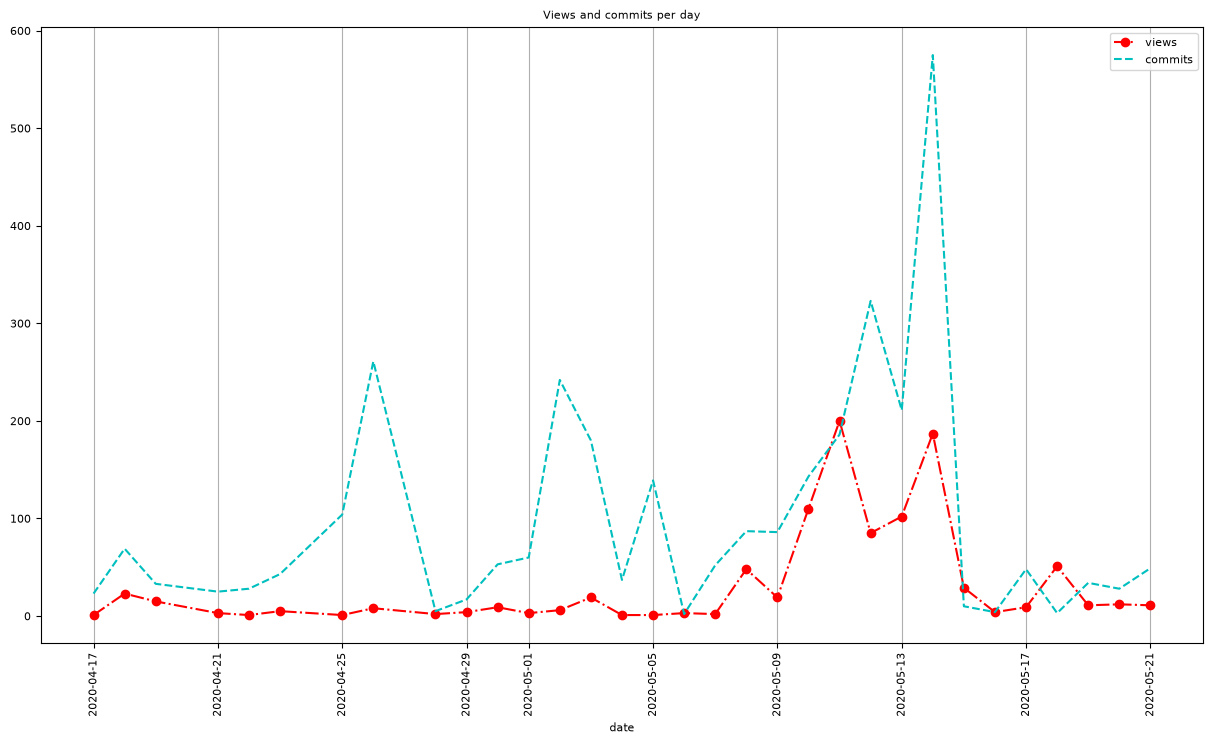

In [238]:
df['dt'] = pd.to_datetime(df['dt'])
fig, ax = plt.subplots(figsize=(15, 8))
ax.plot(df['dt'], df['views'], label='views', linestyle='-.', color='red', marker='o')
ax.plot(df['dt'], df['commits'], label='commits', linestyle='--', color='c')
ax.set_title('Views and commits per day', fontsize=8)
ax.set_xlabel('date', fontsize=8)
ax.tick_params(axis='both', labelsize=8)
ax.legend(fontsize=8)
ax.grid(axis='x')
plt.xticks(rotation=90)
plt.show()

In [239]:
conn.close()

Сколько раз число просмотров превышало 150?

Ответ 2